In our course we understand how we can train the neural network using backpropagation with gradient descent. We know we have some hyperparameters that we should set them by hand. One of this hyperparameters is **Learning rate**. The learning rate magnitude our weights in order to minimize the lost function.

In order to get better results we should choose our learning rate not to big and not too small!

From **Coursera**:
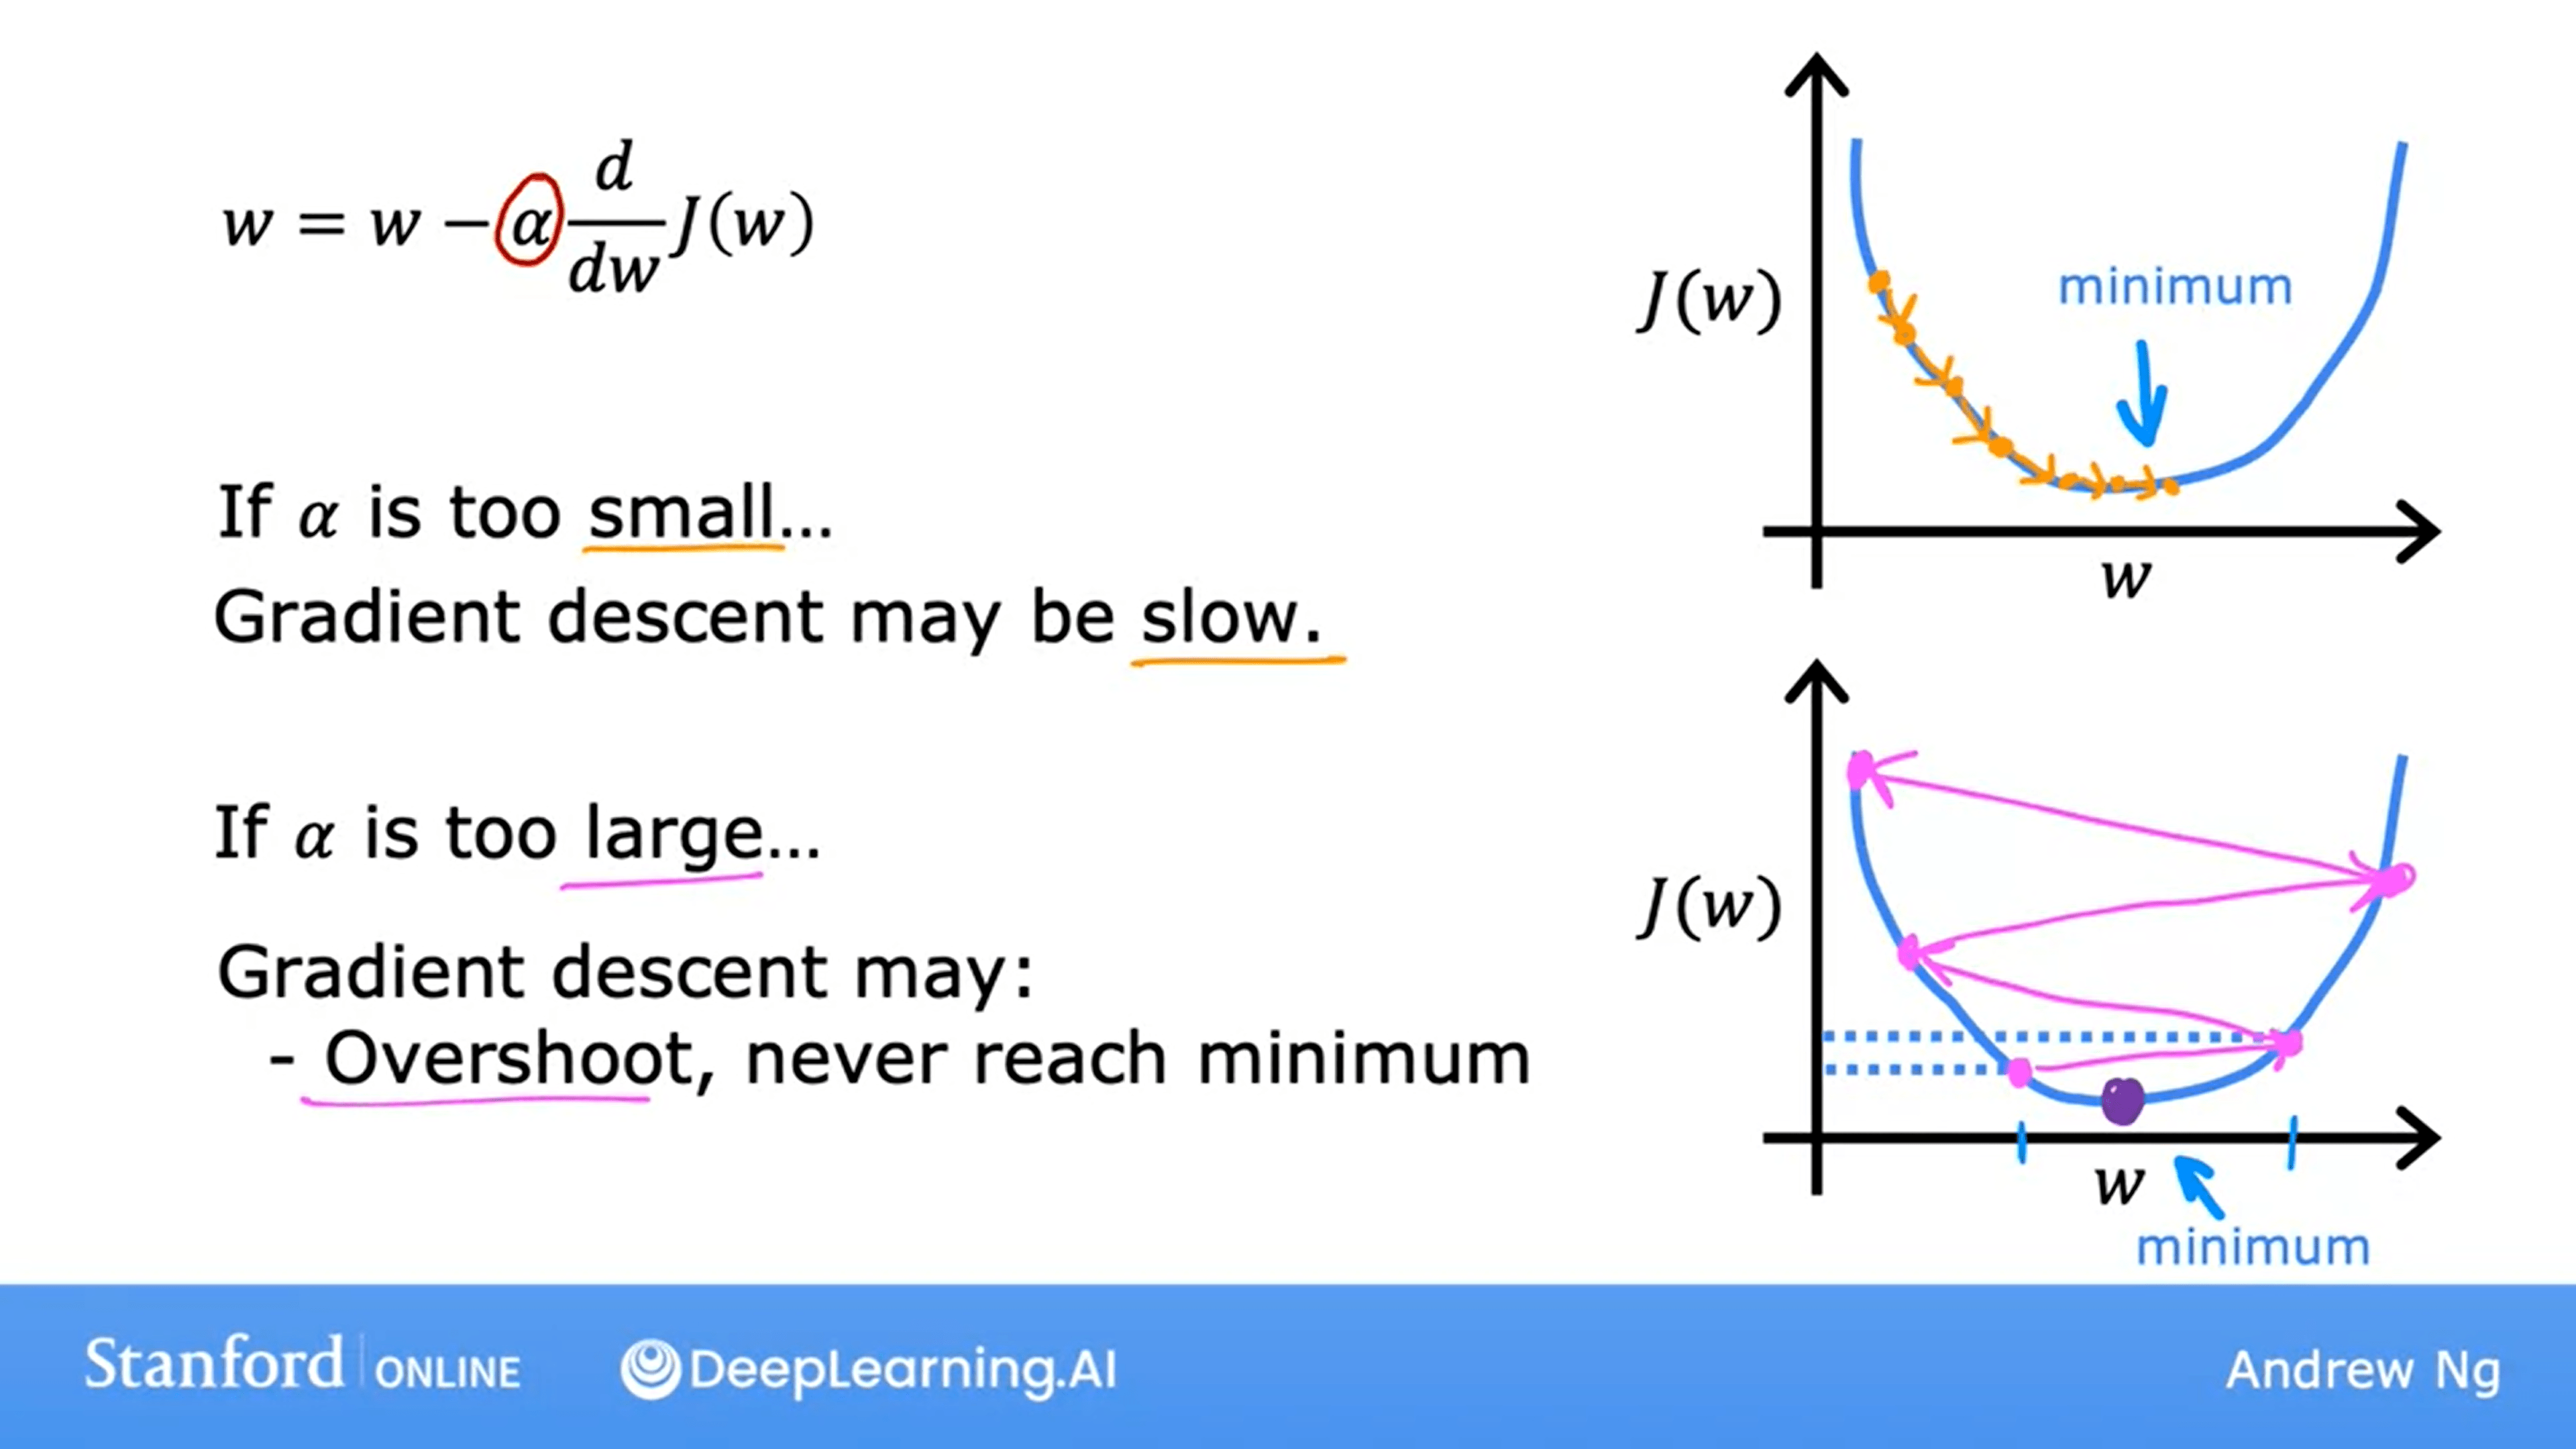

So it is important to choose the learning rate correctly, in order to get the better result.

With this Link below we can see that even the loss function for the neural networks with same architectures.
https://www.cs.umd.edu/~tomg/projects/landscapes/

Good thing is that optimal learning rate is dependent from the both network architecture and the dataset. So we often can improve the performance or speed up training with finding the optimal leanring rate rather than just use the one tha set default based on the deep learning library.

In finding the optimal learning rate we have three different phases.
1. With low learning rate that the loss is high and by increasing the learning rate, the loss start to decresses with the shallow speed.
2. The optimal learning rate phase. In this phase after the lower learning rates we see the really quick decress in the loss function.
3. By increasing the learning rate we reach to the place that the loss function start to diverge. So we understand that these learning rate parameters are high!

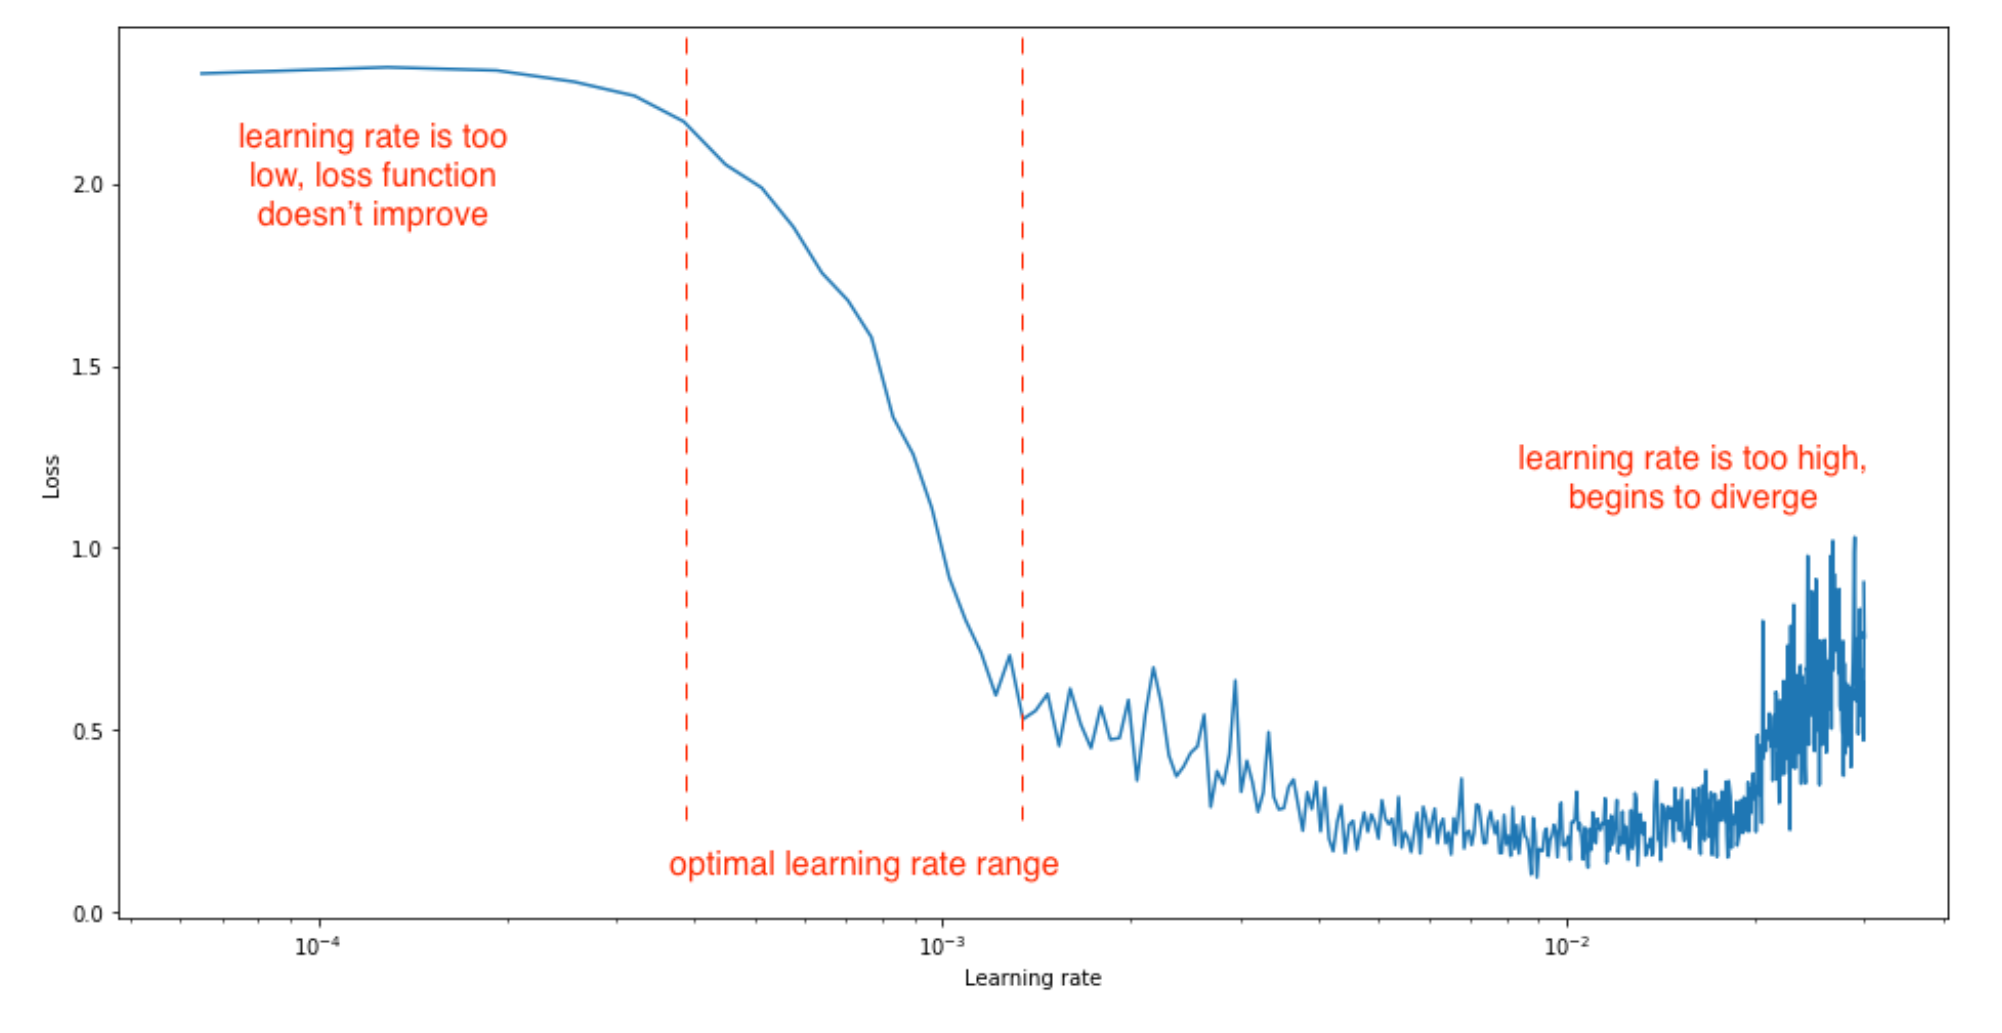

In this notebook I want to use the learning rate annealing method. In this method recommends starting with a relatively high learning rate and then gradually lowering the learning rate during training.

There is no "learning rate schedule" global parameter at the model level. To tamper with the learning rate on the fly, we need to update parameters of the Keras model throughout the training process. This requires using a feature of Keras known as callbacks, which allow us to arbitrarily modify the model in the midst of fitting it.

The rest coding comes from the kaggle notebook: https://www.kaggle.com/code/residentmario/tuning-your-learning-rate/notebook
(With changes and additional code:) )

A good way to implement these adjustments is to make use of the LearningRateScheduler available as a Keras builtin. For example, here's a build for the stepped backoff learning rate schedule:

In [ ]:
#Model building boilerplate

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import SGD

# Generate dummy data
import numpy as np
import pandas as pd

X_train = np.random.random((1000, 3))
y_train = pd.get_dummies(np.argmax(X_train[:, :3], axis=1)).values
X_test = np.random.random((1000, 3))
y_test = pd.get_dummies(np.argmax(X_test[:, :3], axis=1)).values

In [ ]:
#Usign the tensorflow backend
import numpy as np
from keras.callbacks import LearningRateScheduler

#Define a stepped learning rate schedule.
lr_sched = LearningRateScheduler(lambda epoch: 1e-4 * (0.75 ** np.floor(epoch / 2)))

# Build the model.
clf = Sequential()
clf.add(Dense(9, activation='relu', input_dim=3))
clf.add(Dense(9, activation='relu'))
clf.add(Dense(3, activation='softmax'))
clf.compile(loss='categorical_crossentropy', optimizer=SGD())

# Perform training.
clf.fit(X_train, y_train, epochs = 10, batch_size = 500, callbacks=[lr_sched])

Epoch 1/10
2/2 [==============================] - 0s 6ms/step - loss: 1.1204 - lr: 1.0000e-04
Epoch 2/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1204 - lr: 1.0000e-04
Epoch 3/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 7.5000e-05
Epoch 4/10
2/2 [==============================] - 0s 4ms/step - loss: 1.1203 - lr: 7.5000e-05
Epoch 5/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 5.6250e-05
Epoch 6/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 5.6250e-05
Epoch 7/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 4.2188e-05
Epoch 8/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 4.2188e-05
Epoch 9/10
2/2 [==============================] - 0s 5ms/step - loss: 1.1203 - lr: 3.1641e-05
Epoch 10/10
2/2 [==============================] - 0s 7ms/step - loss: 1.1203 - lr: 3.1641e-05


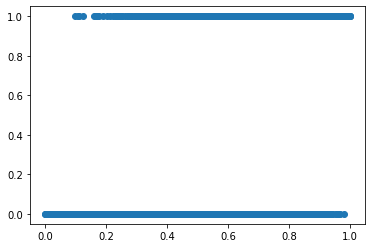

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train)
plt.show()

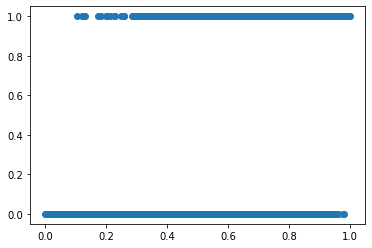

In [ ]:
plt.scatter(X_test, y_test)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_train, y_test)

0.346